## Logistic Regression


### Variable Target: TitleType

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [2]:
df = pd.read_csv('../train_set/train_cleaned_outliers.csv')
print(df['titleType'].value_counts())  # Analisi distribuzione classi

titleType
3    46559
1    26044
0    11648
2     5522
4     3467
Name: count, dtype: int64


Codifica:  
0 - Short  
1 - Movie  
2 - tvSeries  
3 - tvEpisode   
4 - Video  

In [3]:
train = df.drop(columns=['originalTitle'])
# train.head()
test = pd.read_csv('../test_set/test_no_title.csv')
# test.head()

In [4]:
# # Analisi distribuzione target
# plt.figure(figsize=(8, 5))
# train['titleType'].value_counts(normalize=True).plot(kind='bar')
# plt.title('Distribuzione Classi')
# plt.show()

In [5]:
X_train = train.drop(columns=['titleType'])
y_train = train['titleType']

# X_train.head()

In [6]:
X_test = test.drop(columns=['titleType'])
y_test = test['titleType']

# X_test.head()

In [7]:
num_cols = [
    'numVotes', 
    'averageRating', 
    'startYearDecade', 
    'runtimeHours',
    'totalCredits',
    'criticReviewsTotal',
    'userReviewsTotal',
    'castNumber',
    'companiesNumber',
    'writerCredits',
    'directorsCredits',
    'quotesTotal',
    'totalMedia',
    'totalRecognitions',
    ]

one_hot_cols = [
    "genreFamily", "genreDocumentary", "genreNews", "genreFilm-Noir", "genreWestern",
    "genreFantasy", "genreAdult", "genreAction", "genreMusic", "genreComedy",
    "genreSport", "genreHorror", "genreBiography", "genreTalk-Show",
    "genreDrama", "genreRomance", "genreWar", "genreMystery", "genreHistory",
    "genreSci-Fi", "genreAnimation", "genreAdventure", "genreReality-TV",
    "genreMusical", "genreThriller", "genreGame-Show", "genreCrime"
]

### LogReg with MinMax Scaler

In [8]:
scaler = MinMaxScaler()
X_train_scaled_num = pd.DataFrame(
    scaler.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)
X_test_scaled_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

X_train_onehot = X_train[one_hot_cols]
X_test_onehot = X_test[one_hot_cols]

# concatenate them
X_train_temp = pd.concat([X_train_scaled_num, X_train_onehot], axis=1)
X_test_temp = pd.concat([X_test_scaled_num, X_test_onehot], axis=1)

# oroginal order of columns
original_cols = [col for col in X_train.columns if col in num_cols + one_hot_cols]

X_train_scaled = X_train_temp[original_cols]
X_test_scaled = X_test_temp[original_cols]

In [9]:
# # logreg = LogisticRegression(
# #     multi_class='multinomial',  # meglio per multiclass
# #     solver='saga',              # supporta l1/l2, efficiente con grandi dataset
# #     max_iter=1000,              # aumentato per assicurare convergenza
# #     class_weight='balanced',    # utile se le classi sono sbilanciate
# #     random_state=42
# # )

# # # param grid
# # param_grid = {
# #     'C': np.logspace(-3, 2, 6),             # forza della regolarizzazione, crea [0.001, 0.01, 0.1, 1, 10, 100]
# #     'penalty': ['l1', 'l2', 'elasticnet'],  # tipi di regolarizzazione
# #     'class_weight': [None, 'balanced'],
# #     'l1_ratio': [0.0, 0.5, 1.0]             # solo usato se penalty='elasticnet'
# # }

# from sklearn.experimental import enable_halving_search_cv
# from sklearn.model_selection import HalvingGridSearchCV

# logreg = LogisticRegression(
#     multi_class='multinomial',  # meglio per multiclass
#     solver='saga',              # supporta l1/l2, efficiente con grandi dataset
#     max_iter=2000,              # aumentato per assicurare convergenza
#     tol = 1e-4,          # tolleranza per la convergenza
#     random_state=42
# )

# # param grid
# param_grid = {
#     'C': np.logspace(-3, 2, 20),             # forza della regolarizzazione, crea [0.001, 0.01, 0.1, 1, 10, 100]
#     'penalty': ['l1', 'l2', 'elasticnet'],  # tipi di regolarizzazione
#     'class_weight': [None, 'balanced'],
#     'l1_ratio': [0.0, 0.2, 0.5, 0.7, 1.0]             # solo usato se penalty='elasticnet'
# }

# # gridsearch
# halving_search = HalvingGridSearchCV(
#     estimator=logreg,
#     param_grid=param_grid,
#     scoring='f1_macro',
#     cv=9,
#     factor=1.3,           # Elimina 2/3 delle combinazioni ad ogni step
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

# halving_search.fit(X_train_scaled, y_train)

In [ ]:
# # save best model
# best_model = halving_search.best_estimator_
# joblib.dump(best_model, './models/logreg_titleType.pkl')

['./models/logreg_titleType.pkl']

In [11]:
# load model logreg_minMaxScaled_new
best_model = joblib.load('./models/logreg_titleType.pkl')

print("Migliori iperparametri:", best_model.get_params())

Migliori iperparametri: {'C': 100.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 2000, 'multi_class': 'multinomial', 'n_jobs': None, 'penalty': 'l1', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [12]:

y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))


# print best params


              precision    recall  f1-score   support

           0       0.82      0.84      0.83      4133
           1       0.86      0.85      0.86     10302
           2       0.72      0.83      0.77      2528
           3       0.89      0.89      0.89     18059
           4       0.49      0.31      0.38      1273

    accuracy                           0.85     36295
   macro avg       0.76      0.75      0.75     36295
weighted avg       0.85      0.85      0.85     36295



In [13]:
# store model
joblib.dump(best_model, './models/logreg_titleType_minMaxScaled.pkl')

['./models/logreg_titleType_minMaxScaled.pkl']

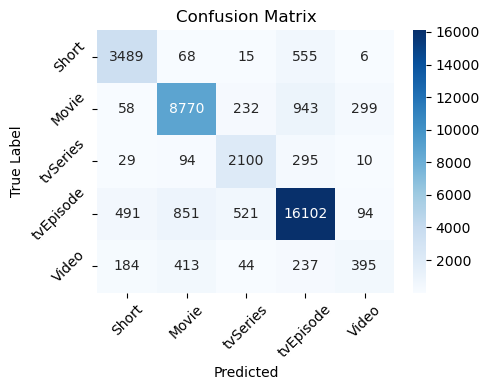

In [ ]:
# ...existing code...
label_map = {
    0: 'Short',
    1: 'Movie',
    2: 'tvSeries',
    3: 'tvEpisode',
    4: 'Video'
}

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))

# Crea le label per gli assi usando il mapping
class_labels = [label_map[i] for i in sorted(np.unique(y_test))]

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_labels,  # Label testuali per asse X
    yticklabels=class_labels   # Label testuali per asse Y
)

plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.tight_layout()  # Per migliorare il layout
plt.show()


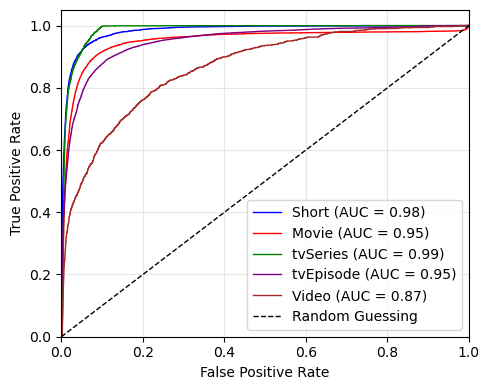


ROC AUC per classe:
Short: 0.982
Movie: 0.950
tvSeries: 0.985
tvEpisode: 0.950
Video: 0.865

ROC AUC media: 0.947


In [ ]:
# ...existing code...
# ROC curve per multiclass
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizza solo le etichette di test
y_test_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
n_classes = y_test_bin.shape[1]

# Usa predict_proba per ottenere le probabilità
y_pred_proba = best_model.predict_proba(X_test_scaled)

# Calcola le curve ROC e AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot delle curve ROC
plt.figure(figsize=(5, 4))
colors = ['blue', 'red', 'green', 'purple', 'brown', 'orange']

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i], 
        color=colors[i % len(colors)],
        lw=1,
        label=f'{label_map[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcola anche la ROC AUC media
print(f"\nROC AUC per classe:")
for i in range(n_classes):
    print(f"{label_map[i]}: {roc_auc[i]:.3f}")
print(f"\nROC AUC media: {np.mean(list(roc_auc.values())):.3f}")
# ...existing code...